## SciPy 优化器
SciPy 的 optimize 模块提供了常用的数值优化与方程求解算法实现。 我们可以直接调用这些函数来解决实际问题，例如查找函数的最小值、最大值，或者求解方程的根等。

NumPy 本身主要关注数组计算和线性代数运算，它提供了用于多项式求根的工具（如 numpy.roots）， 但并未提供通用的非线性方程数值求根接口。 当我们需要求解一般形式的非线性方程时，就需要使用 SciPy 的优化模块。

例如下面的非线性方程：<br>
<b>$ x + cos(x) = 0 $</b>

对于这类问题，可以使用 scipy.optimize.root 函数来求解。 该函数常用的两个核心参数如下：

- fun - 表示方程的函数（返回值为 0 时即表示找到方程的根）
- x0 - 根的初始猜测值
root 函数返回一个结果对象（OptimizeResult）， 其中包含求解状态、是否成功、函数值以及最终解等信息。

实际求得的解保存在返回对象的 x 属性中，示例如下：

In [90]:
# 示例
from scipy.optimize import root
from math import cos

def eqn(x):
    return x + cos(x)

myroot = root(eqn, 0)

print(myroot.x)
# 查看更多信息
# print(myroot)

[-0.73908513]


C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_15692\3527450309.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return x + cos(x)


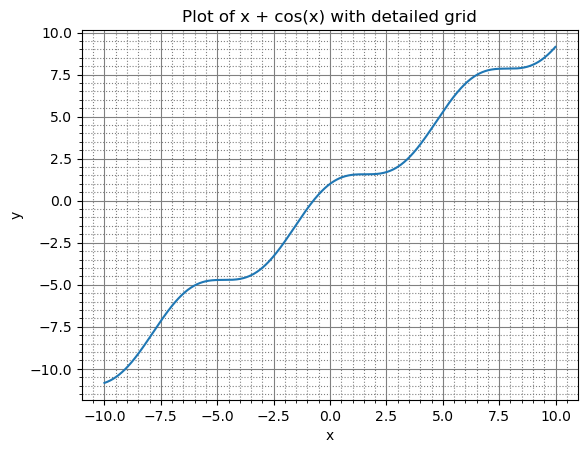

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from math import cos

def eqn(x):
    return x + np.cos(x)

x = np.arange(-10, 10 , 0.01)
y = eqn(x)
plt.plot(x, y)

# 更详细的网格设置
plt.grid(True, linestyle='-', alpha=1, color='gray')
plt.minorticks_on()  # 开启次刻度
plt.grid(which='minor', linestyle=':', alpha=1, color='gray')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot of x + cos(x) with detailed grid')
plt.show()

In [92]:
# 显示详细信息
# 示例
from scipy.optimize import root


def eqn(x):
    return x + np.cos(x)

myroot = root(eqn, 0)

# print(myroot.x)
# 查看更多信息
print(myroot)

# sucess 表示算法是否成功收敛
# message 描述求解过程的结果说明
# x 是求解得到的根
# nfev 是函数评估次数
# fjac 是雅可比矩阵

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00]
       x: [-7.391e-01]
  method: hybr
    nfev: 9
    fjac: [[-1.000e+00]]
       r: [-1.674e+00]
     qtf: [-2.668e-13]


### 最小化函数
在数学和工程问题中，函数通常可以表示为一条曲线， 而曲线往往存在高点和低点。

曲线的高点称为最大值。

曲线的低点称为最小值。

整条曲线中的最高点称为全局最大值， 其余较高但不是最高的点称为局部最大值。同理，整条曲线中的最低点称为全局最小值， 其余较低但不是最低的点称为局部最小值。

在 SciPy 中，可以使用 scipy.optimize.minimize() 函数来寻找函数的最小值。

minimize() 函数常用参数说明如下：

- fun - 需要最小化的目标函数

- x0 - 自变量的初始猜测值

- method - 使用的优化算法名称， 常见可选值包括： 'CG'、'BFGS'、'Newton-CG'、 'L-BFGS-B'、'TNC'、 'COBYLA'、'SLSQP'

- callback - 每次迭代结束后调用的回调函数

- options - 其他控制参数的字典，例如：
```
{
    'maxiter': 1000,  # 最大迭代次数
    'disp': True,     # 是否显示优化过程信息
    'gtol': 1e-6      # 梯度收敛容差
}
```

In [93]:
# 实例
# 使用 BFGS 方法最小化函数 x^2 + x + 2:
from scipy.optimize import minimize

def eqn(x):
    return x**2 + x + 2

mymin = minimize(eqn, 0, method='BFGS')
print(mymin)


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.75
        x: [-5.000e-01]
      nit: 2
      jac: [ 0.000e+00]
 hess_inv: [[ 5.000e-01]]
     nfev: 8
     njev: 4
